In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score

# SMOTE와 Pipeline 
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [2]:
# 1. 데이터 로드
url = "https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

## K-Nearest Neighbors

### Cell 1: 데이터 로드 및 Feature Engineering

In [9]:
df.columns = df.columns.str.strip()
df.rename(columns={'Temperature_T0': 'Temperature_J0'}, inplace=True)

# 2. 결측치 없는 클린 데이터 분리
df_clean = df.dropna().copy()

# 3. 파생 변수 생성 (Power = Current * Speed 등)
current_cols = [f'Current_J{i}' for i in range(6)]
speed_cols = [f'Speed_J{i}' for i in range(6)]
temp_cols = [f'Temperature_J{i}' for i in range(6)]
for i in range(6):
    df_clean[f'Power_J{i}'] = df_clean[f'Current_J{i}'] * df_clean[f'Speed_J{i}']

df_clean['Total_Power_Electric'] = (df_clean[current_cols]**2).sum(axis=1)

# 4. 입력 피처(X) 설정
input_cols = current_cols + speed_cols + temp_cols + ['Tool_current'] + [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric']
X = df_clean[input_cols]

print(f"데이터 크기: {df_clean.shape}")
print(f"피처 개수: {len(input_cols)}개")

데이터 크기: (7355, 31)
피처 개수: 26개


### Cell 2: 타겟 변수 라벨링

In [10]:
# 통합 이진 타겟(System_Failure) 생성
df_clean['Robot_ProtectiveStop'] = df_clean['Robot_ProtectiveStop'].astype(bool).astype(int)
df_clean['grip_lost'] = df_clean['grip_lost'].astype(bool).astype(int)

y = ((df_clean['Robot_ProtectiveStop'] == 1) | (df_clean['grip_lost'] == 1)).astype(int)

print("분류된 타겟(y)의 클래스별 데이터 개수:")
print(y.value_counts().sort_index())

분류된 타겟(y)의 클래스별 데이터 개수:
0    6837
1     518
Name: count, dtype: int64


### Cell 3: 데이터 분할 및 스케일링

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"학습 데이터 크기: {X_train_scaled.shape}")
print(f"테스트 데이터 크기: {X_test_scaled.shape}")

학습 데이터 크기: (5884, 26)
테스트 데이터 크기: (1471, 26)


### Cell 4: SMOTE 적용 KNN 학습 및 하이퍼파라미터 튜닝
가까운 이웃 몇 명을 볼 것인지(n_neighbors)와 거리를 잴 때 가중치를 줄 것인지(weights) 탐색합니다.

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Imblearn Pipeline 구축 (SMOTE -> KNN)
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

# 파라미터 그리드 
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],     # 주변 몇 명을 확인할 것인가
    'knn__weights': ['uniform', 'distance'],  # 가까운 놈한테 더 가중치를 줄 것인가
    'knn__metric': ['euclidean', 'manhattan'] # 거리 측정 공식
}

print("--- [SMOTE] KNN 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---")
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=skf, 
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\n[GridSearchCV 결과]")
print("[최적의 하이퍼파라미터 설정]")
for param, value in grid_search.best_params_.items():
    print(f"  • {param.replace('knn__', '')}: {value}")
print("")
print(f"최고 교차 검증 F1-Macro 점수: {grid_search.best_score_:.4f}")

--- [SMOTE] KNN 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits

[GridSearchCV 결과]
[최적의 하이퍼파라미터 설정]
  • metric: manhattan
  • n_neighbors: 3
  • weights: distance

최고 교차 검증 F1-Macro 점수: 0.6934


### Cell 5: 상위 10개 모델 비교 데이터프레임

In [13]:
cv_results_df = pd.DataFrame(grid_search.cv_results_)
top_models = cv_results_df.sort_values('rank_test_score').head(10)

comparison_data = []
print("--- [모델 비교] 상위 10개 KNN 성능 종합 ---")

for index, row in top_models.iterrows():
    params = row['params']
    rank = int(row['rank_test_score'])
    cv_f1 = row['mean_test_score']
    
    # 해당 파라미터로 재학습
    model = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('knn', KNeighborsClassifier(
            n_neighbors=params.get('knn__n_neighbors', 5),
            weights=params.get('knn__weights', 'uniform'),
            metric=params.get('knn__metric', 'euclidean')
        ))
    ])
    model.fit(X_train_scaled, y_train)
    
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_roc_auc = roc_auc_score(y_test, y_test_prob)
    
    n_val = params.get('knn__n_neighbors', '-')
    w_val = params.get('knn__weights', '-')
    m_val = params.get('knn__metric', '-')
    param_short = f"N={n_val}, W={w_val[:3]}, M={m_val[:3]}"
    
    comparison_data.append({
        '순위': rank,
        'CV F1': round(cv_f1, 4),
        'Train F1': round(train_f1, 4),
        'Test F1': round(test_f1, 4),
        '과적합 Gap': round(train_f1 - test_f1, 4), 
        'Train Acc': round(train_acc, 6),
        'Test Acc': round(test_acc, 6),
        'Test ROC-AUC': round(test_roc_auc, 6),
        '파라미터 설정': param_short
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

--- [모델 비교] 상위 10개 KNN 성능 종합 ---


,순위,CV F1,Train F1,Test F1,과적합 Gap,Train Acc,Test Acc,Test ROC-AUC,파라미터 설정
0,1,0.6934,1.0000,0.7183,0.2817,1.000000,0.901428,0.846840,"N=3, W=dis, M=man"
1,2,0.6922,0.8607,0.7169,0.1437,0.952583,0.899388,0.845806,"N=3, W=uni, M=man"
2,3,0.6893,0.8553,0.7131,0.1422,0.950204,0.898029,0.848348,"N=3, W=uni, M=euc"
3,4,0.6891,1.0000,0.7183,0.2817,1.000000,0.901428,0.849713,"N=3, W=dis, M=euc"
4,5,0.6804,1.0000,0.7179,0.2821,1.000000,0.891230,0.872278,"N=5, W=dis, M=euc"
5,6,0.6799,1.0000,0.7171,0.2829,1.000000,0.893950,0.885396,"N=5, W=dis, M=man"
6,7,0.6741,0.8016,0.7102,0.0914,0.923351,0.885792,0.870741,"N=5, W=uni, M=euc"
7,8,0.6718,0.8090,0.7086,0.1004,0.927430,0.889191,0.883673,"N=5, W=uni, M=man"
8,9,0.6718,1.0000,0.7187,0.2813,1.000000,0.886472,0.880339,"N=7, W=dis, M=euc"
9,10,0.6702,1.0000,0.7137,0.2863,1.000000,0.887152,0.900621,"N=7, W=dis, M=man"


### Cell 6: 특정 순위 모델 최종 평가지표 상세 분석

In [22]:
print("\n" + "="*50)
# ==========================================
target_rank = 2
# ==========================================
print(f"--- [상세 분석] {target_rank}위 모델 최종 평가지표 ---")
print("="*50)

selected_row = top_models[top_models['rank_test_score'] == target_rank].iloc[0]
selected_params = selected_row['params']

print(f"\n[선택된 {target_rank}위 모델의 하이퍼파라미터]")
for param, value in selected_params.items():
    print(f"  • {param.replace('knn__', '')}: {value}")

selected_model = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(
        n_neighbors=selected_params.get('knn__n_neighbors', 5),
        weights=selected_params.get('knn__weights', 'uniform'),
        metric=selected_params.get('knn__metric', 'euclidean')
    ))
])
selected_model.fit(X_train_scaled, y_train)

y_train_pred_selected = selected_model.predict(X_train_scaled)
y_train_prob_selected = selected_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_selected = selected_model.predict(X_test_scaled)
y_test_prob_selected = selected_model.predict_proba(X_test_scaled)[:, 1]

def print_metrics(y_true, y_pred, y_prob, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    roc_auc = roc_auc_score(y_true, y_prob)
    
    print(f"\n[{dataset_name} 데이터 평가]")
    print(f"Accuracy (정확도) : {acc:.4f}")
    print(f"F1-Macro Score    : {f1_macro:.6f}")
    print(f"ROC-AUC Score     : {roc_auc:.6f}")
    print(f"\n[{dataset_name} 상세 분류 리포트]")
    print(classification_report(y_true, y_pred, target_names=['0 (Normal)', '1 (Failure)']))

print_metrics(y_train, y_train_pred_selected, y_train_prob_selected, "Train")
print_metrics(y_test, y_test_pred_selected, y_test_prob_selected, "Test")

y_test_pred = y_test_pred_selected


--- [상세 분석] 2위 모델 최종 평가지표 ---

[선택된 2위 모델의 하이퍼파라미터]
  • metric: manhattan
  • n_neighbors: 3
  • weights: uniform

[Train 데이터 평가]
Accuracy (정확도) : 0.9526
F1-Macro Score    : 0.860673
ROC-AUC Score     : 0.999567

[Train 상세 분류 리포트]
              precision    recall  f1-score   support

  0 (Normal)       1.00      0.95      0.97      5470
 1 (Failure)       0.60      1.00      0.75       414

    accuracy                           0.95      5884
   macro avg       0.80      0.97      0.86      5884
weighted avg       0.97      0.95      0.96      5884


[Test 데이터 평가]
Accuracy (정확도) : 0.8994
F1-Macro Score    : 0.716924
ROC-AUC Score     : 0.845806

[Test 상세 분류 리포트]
              precision    recall  f1-score   support

  0 (Normal)       0.97      0.92      0.94      1367
 1 (Failure)       0.38      0.68      0.49       104

    accuracy                           0.90      1471
   macro avg       0.68      0.80      0.72      1471
weighted avg       0.93      0.90      0.91      1471


### Cell 7: 오차 행렬(Confusion Matrix) 시각화 
(참고: KNN은 수식이나 규칙이 없이 거리만 계산하므로 피처 중요도(Feature Importance)를 도출할 수 없습니다.)

--- [SMOTE + KNN] 1위 모델 오차 행렬 ---


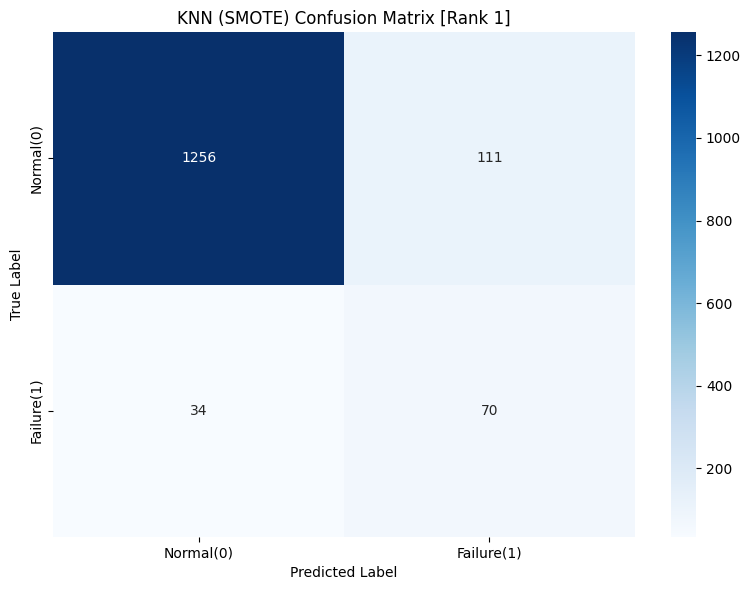

In [16]:
# ==========================================
target_rank_cm = 1  
# ==========================================
print(f"--- [SMOTE + KNN] {target_rank_cm}위 모델 오차 행렬 ---")

plot_row_cm = top_models[top_models['rank_test_score'] == target_rank_cm].iloc[0]
plot_params_cm = plot_row_cm['params']

model_cm = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(
        n_neighbors=plot_params_cm.get('knn__n_neighbors', 5),
        weights=plot_params_cm.get('knn__weights', 'uniform'),
        metric=plot_params_cm.get('knn__metric', 'euclidean')
    ))
])
model_cm.fit(X_train_scaled, y_train)
y_test_pred_cm = model_cm.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred_cm)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=['Normal(0)', 'Failure(1)'], yticklabels=['Normal(0)', 'Failure(1)'])
plt.title(f'KNN (SMOTE) Confusion Matrix [Rank {target_rank_cm}]')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### Cell 8: PCA 2D 결정 경계 시각화

--- [SMOTE + KNN] 1위 모델 2D 결정 경계 시각화 ---
[적용된 1위 모델 파라미터]
  • metric: manhattan
  • n_neighbors: 3
  • weights: distance


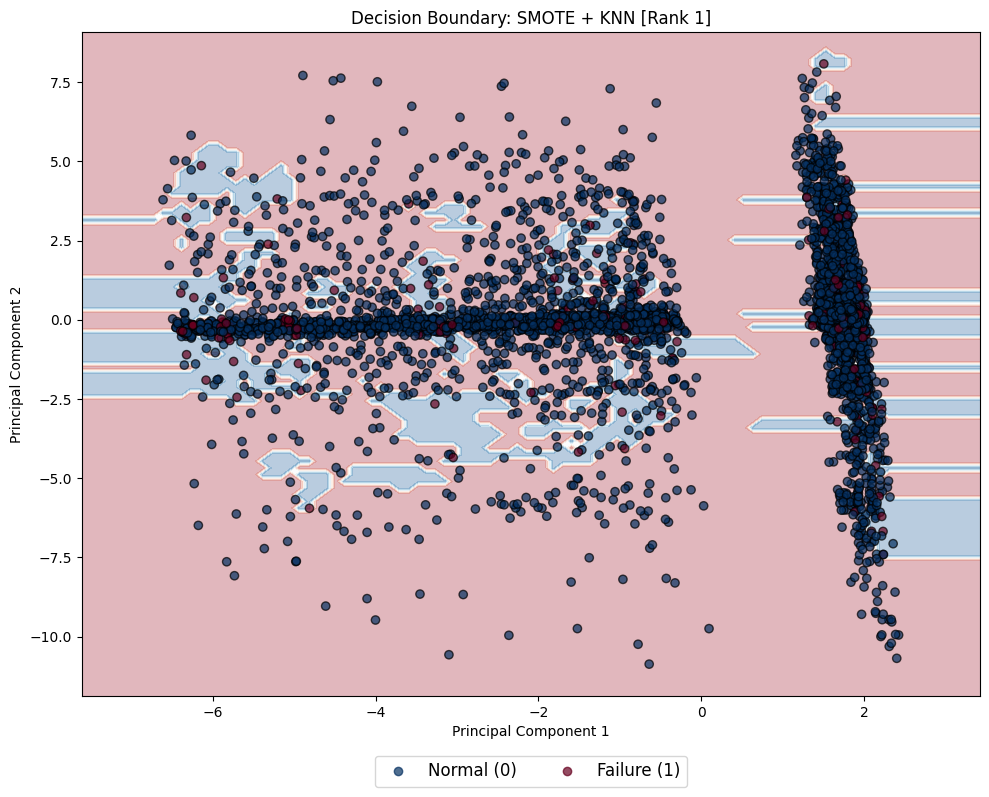

In [17]:
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay

# ==========================================
target_rank_plot = 1  
# ==========================================
print(f"--- [SMOTE + KNN] {target_rank_plot}위 모델 2D 결정 경계 시각화 ---")

plot_row = top_models[top_models['rank_test_score'] == target_rank_plot].iloc[0]
plot_params = plot_row['params']

print(f"[적용된 {target_rank_plot}위 모델 파라미터]")
for param, value in plot_params.items():
    print(f"  • {param.replace('knn__', '')}: {value}")

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

model_smote_pca = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(
        n_neighbors=plot_params.get('knn__n_neighbors', 5),
        weights=plot_params.get('knn__weights', 'uniform'),
        metric=plot_params.get('knn__metric', 'euclidean')
    ))
])
model_smote_pca.fit(X_train_pca, y_train)

fig, ax = plt.subplots(figsize=(10, 8))

DecisionBoundaryDisplay.from_estimator(
    model_smote_pca, X_train_pca, response_method="predict",
    cmap=plt.cm.RdBu, alpha=0.3, ax=ax
)

scatter_kwargs = {'edgecolors': 'k', 'alpha': 0.7}
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.RdBu_r, **scatter_kwargs)

ax.set_title(f"Decision Boundary: SMOTE + KNN [Rank {target_rank_plot}]")
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')

handles, labels = scatter.legend_elements()
ax.legend(handles, ['Normal (0)', 'Failure (1)'], loc='lower center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
plt.show()

### Cell 9: ROC Curve 및 PR Curve

--- [SMOTE + KNN] 2위 모델 ROC / PR Curve ---


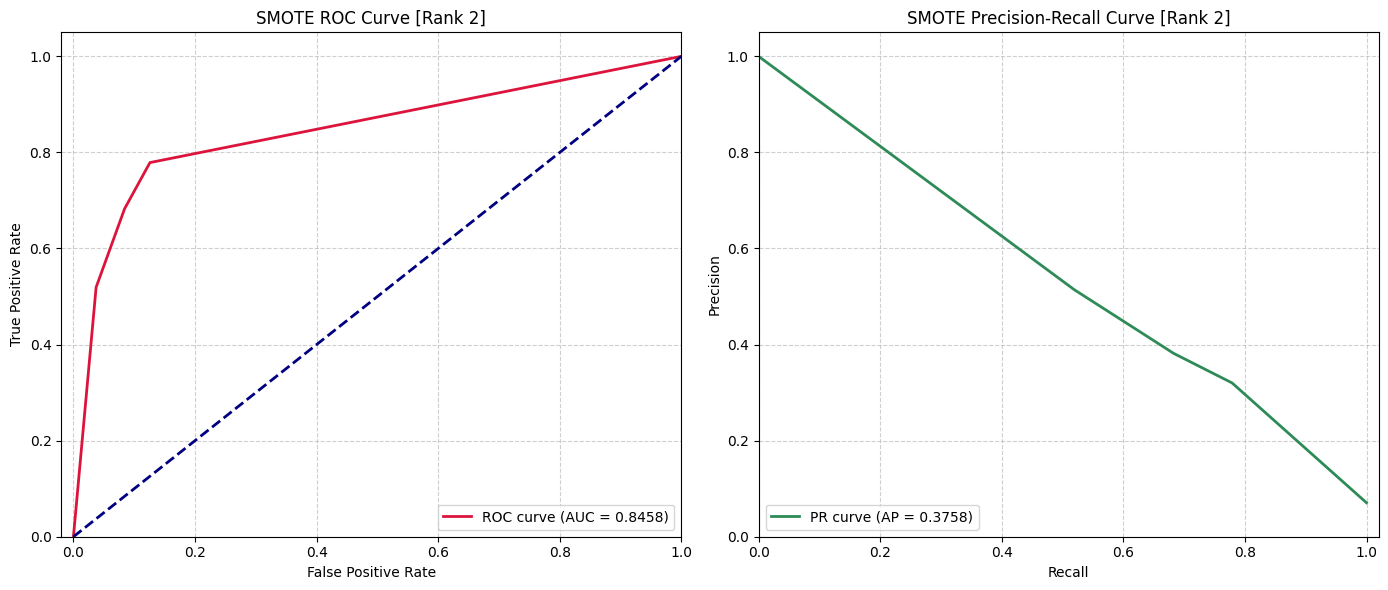

In [24]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# ==========================================
target_rank_curve = 2
# ==========================================
print(f"--- [SMOTE + KNN] {target_rank_curve}위 모델 ROC / PR Curve ---")

plot_row_curve = top_models[top_models['rank_test_score'] == target_rank_curve].iloc[0]
plot_params_curve = plot_row_curve['params']

model_curve = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(
        n_neighbors=plot_params_curve.get('knn__n_neighbors', 5),
        weights=plot_params_curve.get('knn__weights', 'uniform'),
        metric=plot_params_curve.get('knn__metric', 'euclidean')
    ))
])
model_curve.fit(X_train_scaled, y_train)
y_test_prob_curve = model_curve.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_test_prob_curve)
roc_auc_val = auc(fpr, tpr)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_prob_curve)
pr_auc_val = average_precision_score(y_test, y_test_prob_curve)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr, tpr, color='crimson', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([-0.02, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'SMOTE ROC Curve [Rank {target_rank_curve}]')
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(recall_vals, precision_vals, color='seagreen', lw=2, label=f'PR curve (AP = {pr_auc_val:.4f})')
axes[1].set_xlim([0.0, 1.02])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'SMOTE Precision-Recall Curve [Rank {target_rank_curve}]')
axes[1].legend(loc="lower left")
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()